In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
data = np.load("logs/model_predictions.npz")

In [3]:
y_train=data['y_train']
y_val=data['y_val']
y_test=data['y_test']
y_2017=data['y_2017']
y_2015=data['y_2015']
y_2011=data['y_2011']
predictions_train = data['predictions_train']
predictions_test = data['predictions_test']
predictions_val = data['predictions_val']
predictions_2017=data['predictions_2017']
predictions_2015=data['predictions_2015']
predictions_2011=data['predictions_2011']

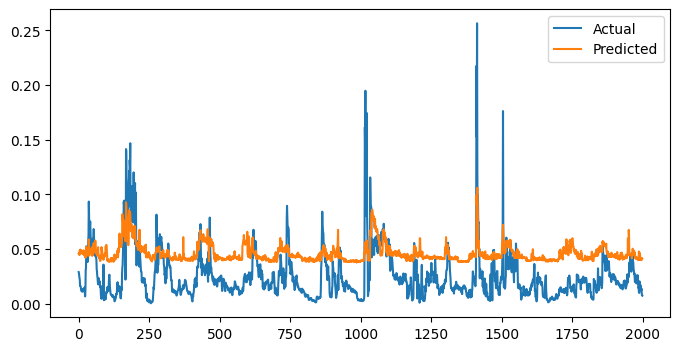

In [4]:
ind = 5
s_timestamp = 10000
e_timestamp = 12000
plt.figure(figsize=(8,4))
plt.plot(y_train[s_timestamp:e_timestamp,ind], label="Actual")
plt.plot(predictions_train[s_timestamp:e_timestamp,ind],label="Predicted")
plt.legend()

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.0.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/var/tmp/ipykernel_227131/2771145934.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


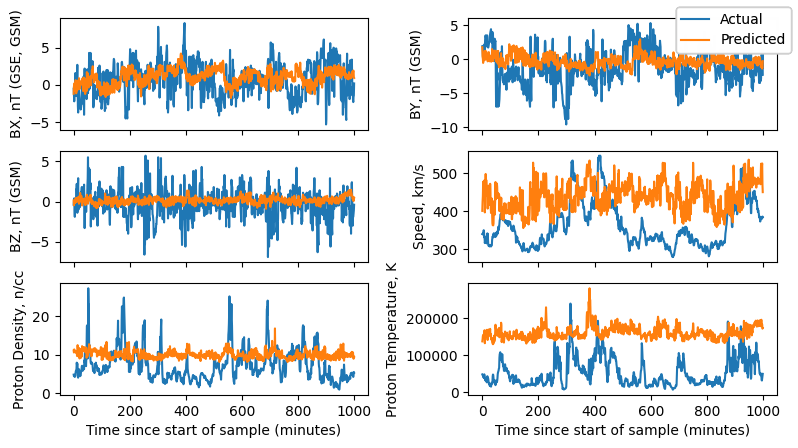

In [5]:
s_timestamp = 0
e_timestamp = 1000

scaler_y = pickle.load(open("logs/scaler_y.scaler",'rb'))
predictions_test = scaler_y.inverse_transform(predictions_test)
y_test = scaler_y.inverse_transform(y_test)

out_feature_names = ['BX, nT (GSE, GSM)',
           'BY, nT (GSM)', 'BZ, nT (GSM)', 'Speed, km/s', 'Proton Density, n/cc',
           'Proton Temperature, K']
fig,axes = plt.subplots(3,2,figsize=(8,4.5), sharex='col')
axes = axes.ravel()

for ind in range(len(out_feature_names)):
    axes[ind].plot(y_test[s_timestamp:e_timestamp,ind], label="Actual"*(not ind))
    axes[ind].plot(predictions_test[s_timestamp:e_timestamp,ind],label="Predicted"*(not ind))
        # axes[ind].tick_params(axis="x", labelrotation=45)
    axes[ind].set_ylabel(out_feature_names[ind])
    plt.tight_layout()
    if (ind==4) or (ind==5):
        axes[ind].set_xlabel("Time since start of sample (minutes)")
    fig.legend()

In [6]:
print(y_test[:,5])

[ 48406.  46479.  45733. ... 117145. 145650. 169617.]


In [7]:
metrics_df = pd.DataFrame(np.zeros((len(out_feature_names),4)), columns=["Target", "RMSE", "MAE", "$r^2$"])
for ind in range(len(out_feature_names)):
    rmse = np.sqrt(mean_squared_error(predictions_test[:, ind], y_test[:, ind]))
    mae = mean_absolute_error(predictions_test[:, ind], y_test[:, ind])
    r2 = r2_score(predictions_test[:, ind], y_test[:, ind])
    metrics_df.iloc[ind] = [out_feature_names[ind], rmse, mae, r2]
metrics_df.head(6)

,Target,RMSE,MAE,$r^2$
0,"BX, nT (GSE, GSM)",2.384977,1.939652,-2.907196
1,"BY, nT (GSM)",2.767833,2.118754,-4.345833
2,"BZ, nT (GSM)",2.072692,1.556320,-26.075460
3,"Speed, km/s",98.665461,86.443875,-7.365460
4,"Proton Density, n/cc",5.454546,4.714925,-19.896833
5,"Proton Temperature, K",116431.894724,109574.457765,-30.911792


In [10]:
persistence = pd.DataFrame(y_test).shift(-60).iloc[:-60].to_numpy()
persistence_metrics_df = pd.DataFrame(np.zeros((len(out_feature_names),4)), columns=["Target", "RMSE", "MAE", "$r^2$"])
for ind in range(len(out_feature_names)):
    rmse = np.sqrt(mean_squared_error(persistence[:, ind], y_test[:-60][:, ind]))
    mae = mean_absolute_error(persistence[:, ind], y_test[:-60][:, ind])
    r2 = r2_score(persistence[:, ind], y_test[:-60][:, ind])
    persistence_metrics_df.iloc[ind] = [out_feature_names[ind], rmse, mae, r2]
persistence_metrics_df.head(6)

,Target,RMSE,MAE,$r^2$
0,"BX, nT (GSE, GSM)",3.231181,2.551618,-0.607444
1,"BY, nT (GSM)",3.497854,2.703462,-0.771416
2,"BZ, nT (GSM)",2.820742,2.136844,-0.959269
3,"Speed, km/s",78.938929,58.597947,-0.102676
4,"Proton Density, n/cc",5.282517,3.737442,-0.715990
5,"Proton Temperature, K",60362.168381,41156.783918,-0.550900


In [47]:
dagger_forecast = np.load("logs/dagger_forecast.npz", allow_pickle=True)
dagger_coeffs = dagger_forecast["Coefficients"].item()
dagger_predictions = dagger_forecast["Predictions"].item()
dagger_times = dagger_forecast["dates"].item()

NameError: name 'MLT_sup_all' is not defined

dict_keys(['dbe', 'dbn'])

ModuleNotFoundError: No module named 'utils.helpers'

NameError: name '_mlt' is not defined

<Figure size 1200x800 with 0 Axes>